In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
from sklearn.cluster import (
    KMeans,
    DBSCAN,
    Birch,
    AgglomerativeClustering,
    SpectralClustering,
    MeanShift
)
from sklearn.cluster import estimate_bandwidth
from sklearn.mixture import GaussianMixture

In [3]:
full = np.load("./data/processed/dataset_full.npz", allow_pickle=True)
X_full = full["X"]
K0_full = full["K0"]

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

In [5]:
# N = 20000

# idx = np.random.choice(len(X_pca), N, replace=False)

X_small = X_pca[::2000]
K0_small = K0_full[::2000]

bandwidth_meanshift = estimate_bandwidth(X_small, quantile=0.2, n_samples=500)

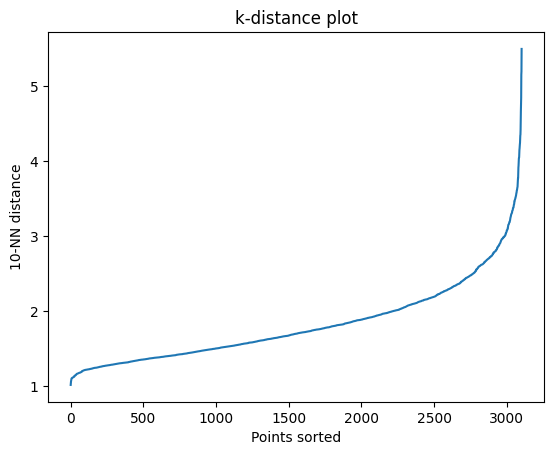

In [6]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_small)

distances, _ = neighbors_fit.kneighbors(X_small)

distances = np.sort(distances[:,9])

plt.plot(distances)
plt.ylabel("10-NN distance")
plt.xlabel("Points sorted")
plt.title("k-distance plot")
plt.show()

In [7]:
for eps in [0.2,0.3,0.4,0.5,0.7,1.0]:
    for m in [5,10,20]:
        labels = DBSCAN(eps=eps, min_samples=m).fit_predict(X_small)
        print(eps, m, np.unique(labels))


for eps in np.linspace(0.7,1.0,10):
    for m in [5,10,20]:
        labels = DBSCAN(eps=eps, min_samples=5, metric="cosine").fit_predict(X_small)
        print(eps, len(set(labels)))

0.2 5 [-1]
0.2 10 [-1]
0.2 20 [-1]
0.3 5 [-1]
0.3 10 [-1]
0.3 20 [-1]
0.4 5 [-1]
0.4 10 [-1]
0.4 20 [-1]
0.5 5 [-1]
0.5 10 [-1]
0.5 20 [-1]
0.7 5 [-1]
0.7 10 [-1]
0.7 20 [-1]
1.0 5 [-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46
 47]
1.0 10 [-1]
1.0 20 [-1]
0.7 1
0.7 1
0.7 1
0.7333333333333333 1
0.7333333333333333 1
0.7333333333333333 1
0.7666666666666666 1
0.7666666666666666 1
0.7666666666666666 1
0.7999999999999999 1
0.7999999999999999 1
0.7999999999999999 1
0.8333333333333333 1
0.8333333333333333 1
0.8333333333333333 1
0.8666666666666667 1
0.8666666666666667 1
0.8666666666666667 1
0.9 1
0.9 1
0.9 1
0.9333333333333333 1
0.9333333333333333 1
0.9333333333333333 1
0.9666666666666667 1
0.9666666666666667 1
0.9666666666666667 1
1.0 1
1.0 1
1.0 1


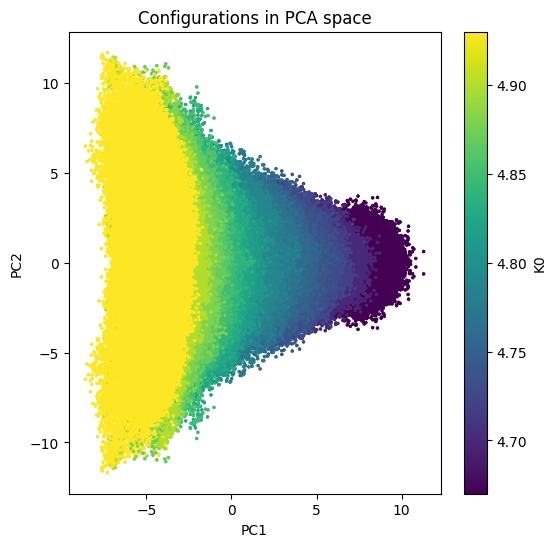

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=K0_full, s=2)
plt.colorbar(label="K0")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Configurations in PCA space")

plt.show()

In [9]:
models_full = {
    "KMeans": KMeans(n_clusters=2, random_state=0),
}


models_small = {
    "Birch": Birch(n_clusters=2),
    "GaussianMixture": GaussianMixture(n_components=2, random_state=0),
    "DBSCAN": DBSCAN(eps=3, min_samples=10),
    "Agglomerative": AgglomerativeClustering(n_clusters=2),
    "Spectral": SpectralClustering(n_clusters=2, affinity="nearest_neighbors"),
    "MeanShift": MeanShift(bandwidth=bandwidth_meanshift)
}

In [10]:
def probability_vs_k0_gmm(model, X, K0):

    model.fit(X)

    probs = model.predict_proba(X)

    means = model.means_

    # identify component corresponding to phase C
    phase_c_component = np.argmax(means[:, 0])

    P_C = probs[:, phase_c_component]

    df = pd.DataFrame({
        "K0": K0,
        "P_C": P_C
    })

    grouped = df.groupby("K0")["P_C"]

    mean_curve = grouped.mean()
    chi_curve = grouped.var()

    return mean_curve, chi_curve

In [11]:
def probability_vs_k0_unsupervised(model, X, K0):

    labels = model.fit_predict(X)

    df = pd.DataFrame({
        "K0": K0,
        "cluster": labels
    })

    # Remove DBSCAN noise if present
    df = df[df.cluster != -1]

    # If no clusters remain → algorithm failed
    if df.empty or df["cluster"].nunique() < 2:
        print(f"{model.__class__.__name__} failed to find 2 clusters")
        return None, None

    # Determine which cluster corresponds to phase C
    cluster_means = df.groupby("cluster")["K0"].mean()
    phase_c_cluster = cluster_means.idxmax()

    df["phase_C"] = (df["cluster"] == phase_c_cluster).astype(float)

    grouped = df.groupby("K0")["phase_C"]

    mean_curve = grouped.mean()
    chi_curve = grouped.var()

    return mean_curve, chi_curve

In [12]:
def extract_k0_crit(chi_series):

    k0_values = chi_series.index.values
    chi_values = chi_series.values

    idx_max = np.argmax(chi_values)

    return k0_values[idx_max], chi_values[idx_max]

In [13]:
results = []
variance_results = {}
curves = {}

In [14]:
# large dataset models
for name, model in models_full.items():

    print("Running", name)

    mean_curve, chi_curve = probability_vs_k0_unsupervised(
        model,
        X_pca,
        K0_full
    )

    k0_crit, chi_max = extract_k0_crit(chi_curve)

    curves[name] = {
        "mean": mean_curve,
        "chi": chi_curve
    }

    results.append({
        "model": name,
        "k0_crit": k0_crit,
        "chi_max": chi_max
    })


Running KMeans


In [15]:
# small dataset models
for name, model in models_small.items():

    print("Running", name)

    if name == "GaussianMixture":

        mean_curve, chi_curve = probability_vs_k0_gmm(
            model,
            X_small,
            K0_small
        )

    else:

        mean_curve, chi_curve = probability_vs_k0_unsupervised(
            model,
            X_small,
            K0_small
        )
        
        if mean_curve is None:
            continue

    k0_crit, chi_max = extract_k0_crit(chi_curve)

    curves[name] = {
        "mean": mean_curve,
        "chi": chi_curve
    }

    results.append({
        "model": name,
        "k0_crit": k0_crit,
        "chi_max": chi_max
    })

Running Birch
Running GaussianMixture
Running DBSCAN
DBSCAN failed to find 2 clusters
Running Agglomerative
Running Spectral
Running MeanShift
MeanShift failed to find 2 clusters


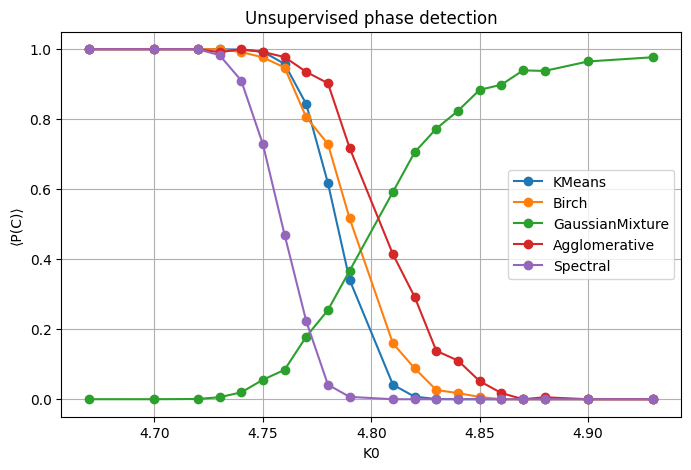

In [16]:
plt.figure(figsize=(8,5))

for name, model_curves in curves.items():

    mean_curve = 1-model_curves["mean"]

    plt.plot(
        mean_curve.index,
        mean_curve.values,
        marker="o",
        label=name
    )

plt.xlabel("K0")
plt.ylabel("⟨P(C)⟩")
plt.title("Unsupervised phase detection")

plt.legend()
plt.grid(True)
plt.show()

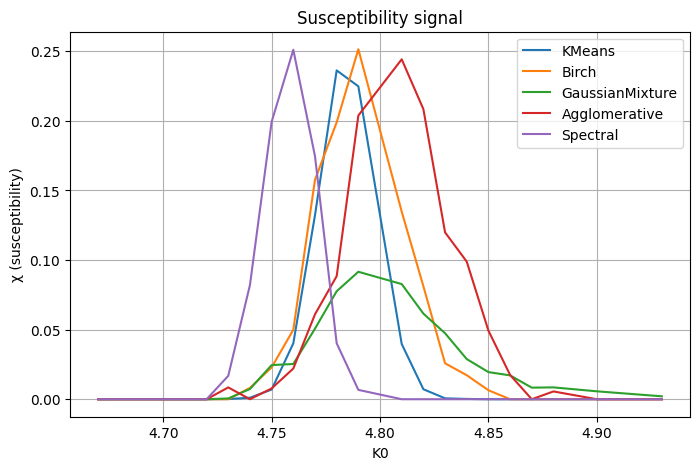

In [17]:
plt.figure(figsize=(8,5))

for name, model_curves in curves.items():

    chi_curve = model_curves["chi"]

    plt.plot(
        chi_curve.index,
        chi_curve.values,
        label=name
    )

plt.xlabel("K0")
plt.ylabel("χ (susceptibility)")
plt.title("Susceptibility signal")

plt.legend()
plt.grid(True)
plt.show()

In [18]:
results_df = pd.DataFrame(results)
print(results_df.sort_values("k0_crit"))

             model  k0_crit   chi_max
4         Spectral     4.76  0.250982
0           KMeans     4.78  0.236195
2  GaussianMixture     4.79  0.091545
1            Birch     4.79  0.251406
3    Agglomerative     4.81  0.244161


In [19]:
candidate_k0 = np.sort(np.unique(K0_full))
print(candidate_k0)

[4.67 4.7  4.72 4.73 4.74 4.75 4.76 4.77 4.78 4.79 4.81 4.82 4.83 4.84
 4.85 4.86 4.87 4.88 4.9  4.93]


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

def confusion_scheme(X, K0, candidate_k0):

    accuracies = []

    for k0_star in candidate_k0:

        y_fake = (K0 > k0_star).astype(int)
        print(k0_star, np.bincount(y_fake))

        # skip if only one class exists
        if len(np.unique(y_fake)) < 2:
            accuracies.append(np.nan)
            continue

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_fake, test_size=0.3, random_state=0
        )

        clf = LogisticRegression(max_iter=2000)

        clf.fit(X_train, y_train)

        acc = clf.score(X_test, y_test)

        accuracies.append(acc)

    return np.array(accuracies)

In [30]:
acc_curve = confusion_scheme(X_pca, K0_full, candidate_k0)

4.67 [ 376596 5829100]
4.7 [ 579212 5626484]
4.72 [ 804192 5401504]
4.73 [1039312 5166384]
4.74 [1286392 4919304]
4.75 [1543576 4662120]
4.76 [1810956 4394740]
4.77 [2089040 4116656]
4.78 [2377028 3828668]
4.79 [2674572 3531124]
4.81 [2988772 3216924]
4.82 [3282624 2923072]
4.83 [3587748 2617948]
4.84 [3931444 2274252]
4.85 [4241056 1964640]
4.86 [4581472 1624224]
4.87 [4915132 1290564]
4.88 [5273580  932116]
4.9 [5637852  567844]
4.93 [6205696]


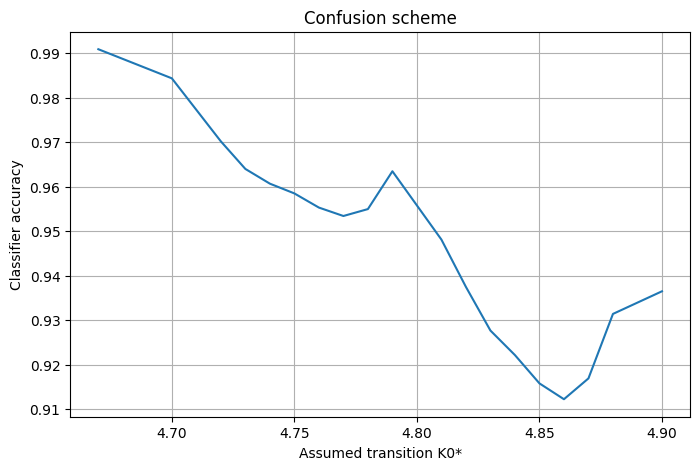

In [31]:
plt.figure(figsize=(8,5))

plt.plot(candidate_k0, acc_curve)

plt.xlabel("Assumed transition K0*")
plt.ylabel("Classifier accuracy")
plt.title("Confusion scheme")

plt.grid(True)
plt.show()